## 所有节点数据建图

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr
from tqdm import tqdm
import warnings
import numpy as np
import glob
import os
import re
import pickle
warnings.filterwarnings("ignore")

# 设置中文字体
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
### 构建器
class EdgeFeatureGraphBuilder:
    """
    构建带有丰富边特征的图
    每条边包含多个特征维度：距离、相关性、方向等
    """

    def __init__(self, base_path, location_file, correlation_matrices=None, files_pattern="dated_Turb*.csv", node_index_file=None):
        """
        初始化边特征图构建器
        
        Parameters:
        base_path: 文件路径
        location_file: 风机位置文件
        correlation_matrices: 多个相关性矩阵
        files_pattern: 风速数据文件模式，如 "dated_Turb*.csv" (可选)
        node_index_file: 风机聚类信息
        """
        assert node_index_file is not None, "请提供 node_index_file 文件路径"
        
        self.base_path = base_path
        self.files_pattern = files_pattern
        

        # 加载节点索引
        self.node_index = np.load(node_index_file, allow_pickle=True)
        for cluster in self.node_index:
            cluster.sort()
        self.num_cluster = len(self.node_index)
        print(f"加载 {self.num_cluster} 个风机簇")
        
        self.num_nodes = 0
        for cluster in self.node_index:
            self.num_nodes += len(cluster)
        print(f"总风机数量: {self.num_nodes}")
        
        self.file_index = []
        for cluster in self.node_index:
            for idx in cluster:
                self.file_index.append(idx)
        self.file_index = np.array(self.file_index)
        self.file_index.sort()
        print(f"风机索引:{self.file_index}")


        self.file_list = [files_pattern.replace('*', str(file_name+1)) for file_name in self.file_index]
        
        # 加载位置数据
        self.location_df = pd.read_csv(os.path.join(base_path, location_file))
        self.coords = self.location_df[["x", "y"]].values
        self.coords = self.coords[np.array(self.file_index)]  # 只保留选定风机的坐标
        # 存储相关性矩阵
        self.correlation_matrices = np.array(correlation_matrices)


        # 聚类分组
        cluster_distances = []
        cluster_matrices = []
        cluster_nodes = []
        cluster_coords = []
        for i, cluster in enumerate(self.node_index):
            cluster.sort()
            cluster_nodes.append(cluster)
            print(f"簇 {i}: 包含 {len(cluster)} 台风机, TurbID: {cluster + 1}")
            # 计算每个簇的距离矩阵
            coords = self.coords[cluster]
            cluster_coords.append(coords)
            distance_matrix = squareform(pdist(coords, "euclidean"))
            cluster_distances.append(distance_matrix)
            print(f"   簇 {i} 的距离矩阵形状: {distance_matrix.shape}")
            cluster_correlation_matrices = self.correlation_matrices[:, cluster, :][:, :, cluster]
            cluster_matrices.append(cluster_correlation_matrices)
            print(f"   簇 {i} 的相关性矩阵形状: {cluster_correlation_matrices.shape}")
        self.cluster_nodes = cluster_nodes
        self.cluster_distances = (cluster_distances)
        self.cluster_matrices = (cluster_matrices)
        self.cluster_coords = (cluster_coords)
        print(f"初始化完成: {self.num_nodes} 个节点")
    
    def load_wind_speed_data(self, train_ratio=0.7, feature_col="Wspd"):
        """
        从CSV文件加载风速数据
        
        Parameters:
        train_ratio: 训练集比例
        feature_col: 特征列名
        
        Returns:
        numpy array: 风速数据矩阵 [num_turbines, timesteps]
        """
        if self.files_pattern is None:
            raise ValueError("未提供风速文件模式，请在初始化时设置 files_pattern")

        data_files = glob.glob(os.path.join(self.base_path, self.files_pattern))
        if len(data_files) == 0:
            raise ValueError(f"未找到匹配的风速数据文件: {self.files_pattern}")
        print(f"找到 {len(data_files)} 个风速数据文件")

        #过滤文件名存在与file_list中
        if self.file_list is not None:
            data_files = [f for f in data_files if os.path.basename(f) in self.file_list]
            print(f"过滤后剩余 {len(data_files)} 个风速数据文件")
        # 提取Turb后面的数字进行排序
        def extract_turb_num(filename):
            basename = os.path.basename(filename)
            match = re.search(r'Turb(\d+)', basename)
            return int(match.group(1)) if match else float('inf')
        data_files.sort(key=extract_turb_num)

        # 检查文件数量与节点数量是否匹配
        if len(data_files) != self.num_nodes:
            print(f"警告: 风速文件数量 ({len(data_files)}) 与节点数量 ({self.num_nodes}) 不匹配")
            # 取较小值
            num_files = min(len(data_files), self.num_nodes)
            data_files = data_files[:num_files]
        else:
            num_files = len(data_files)
        
        # 读取第一个文件确定数据长度
        sample_df = pd.read_csv(data_files[0])
        total_timesteps = len(sample_df)
        train_split = int(train_ratio * total_timesteps)
        print(f"总时间步数: {total_timesteps}, 训练集时间步数: {train_split}")
        
        # 检查特征列是否存在
        if feature_col not in sample_df.columns:
            print(f"特征列 '{feature_col}' 不存在，可用列: {list(sample_df.columns)}")
            raise ValueError(f"特征列 '{feature_col}' 不存在")
        
        # 初始化数组
        wind_speeds = np.zeros((num_files, train_split))
        
        # 加载数据
        for i, file in enumerate(tqdm(data_files, desc="加载风速数据")):
            try:
                df = pd.read_csv(file)
                # 检查数据长度
                if len(df) != total_timesteps:
                    print(f"警告: 文件 {file} 的数据长度不一致")
                    min_length = min(len(df), train_split)
                    wind_speeds[i, :min_length] = df[feature_col].iloc[:min_length].values
                else:
                    wind_speeds[i, :] = df[feature_col].iloc[:train_split].values
                
                # 数据质量检查
                turbine_data = wind_speeds[i, :]
                nan_count = np.isnan(turbine_data).sum()
                zero_count = (turbine_data == 0).sum()
                valid_ratio = (len(turbine_data) - nan_count - zero_count) / len(turbine_data)
                
                if valid_ratio < 0.5:
                    print(f"警告: 风机 {i} 有效数据比例过低 ({valid_ratio:.2%})")
                
                # 处理缺失值
                if np.isnan(turbine_data).any():
                    if valid_ratio > 0.1:
                        mean_val = np.nanmean(turbine_data)
                        if not np.isnan(mean_val):
                            mask = np.isnan(turbine_data)
                            wind_speeds[i, mask] = mean_val
                        else:
                            global_mean = np.nanmean(wind_speeds)
                            wind_speeds[i, :] = global_mean 
            except Exception as e:
                print(f"读取文件 {file} 时出错: {e}")
        
        # 根据cluster分组
        clustered_speeds = []
        for cluster in self.node_index:
            speeds = wind_speeds[cluster,:]
            clustered_speeds.append(speeds)
        self.wind_speed_data = clustered_speeds
        print(f"风速数据加载完成: {len(self.wind_speed_data)}")
        print(f"风速数据形状: {[self.wind_speed_data[i].shape for i in range(len(self.wind_speed_data))]}")
        return self.wind_speed_data

    def compute_spatial_features(self, idx):
        print("计算空间特征...")
        distance_matrix = self.cluster_distances[idx]
        coords = self.cluster_coords[idx]
        num_nodes = len(self.cluster_nodes[idx])
        features = {}      

        # 1. 标准化距离 (0-1)
        print("1. 标准化距离 (0-1)")
        max_dist = np.max(distance_matrix)
        features['normalized_distance'] = distance_matrix / max_dist

        # 2. 高斯距离核
        print("2. 高斯距离核")
        sigma = np.mean(distance_matrix[distance_matrix > 0]) / 3
        features['gaussian_distance'] = np.exp(-(distance_matrix ** 2) / (2 * sigma ** 2))

        # 3. 相对方位角 (弧度)
        print("3. 计算相对方位角 (弧度) 及 sin cos")
        angles = np.zeros((num_nodes, num_nodes))
        for i in range(num_nodes):
            for j in range(num_nodes):
                if i != j:
                    dx = coords[j, 0] - coords[i, 0]
                    dy = coords[j, 1] - coords[i, 1]
                    angles[i, j] = np.arctan2(dy, dx)
        features['bearing_angle'] = angles

        # 4. 方位角的sin和cos分量 (便于神经网络处理)
        features['bearing_sin'] = np.sin(angles)
        features['bearing_cos'] = np.cos(angles)
        
        return features
    
    def compute_correlation_features(self, idx):
        print("计算相关性特征...")

        correlation_matrices = self.cluster_matrices[idx]

        features = {}
        
        print("1. 原始相关性")
        features['pearson_correlation'] = correlation_matrices[0].copy()

        print("2. 差分相关性")
        features['pearson_diff_correlation'] = correlation_matrices[1].copy()

        print("3. 方向相关性")
        features['direction_correlation'] = correlation_matrices[2].copy()

        print("4. 加权相关性")
        features['weighted_correlation'] = features['pearson_correlation'] * 0.2 + features['pearson_diff_correlation']*0.4 + features['direction_correlation']*0.4

        return features
    
    def compute_statistical_features(self,idx):
        print("计算统计特征...")
        num_nodes = len(self.cluster_nodes[idx])
        wind_speed_data = self.wind_speed_data[idx]
        features = {}
        
        # 计算每对风机的统计特征
        lag_correlation = np.zeros((num_nodes, num_nodes))
        variance_ratio = np.zeros((num_nodes, num_nodes))
        mean_diff = np.zeros((num_nodes, num_nodes))

        for i in range(num_nodes):
            for j in range(num_nodes):
                if i != j:
                    data_i = wind_speed_data[i, :]
                    data_j = wind_speed_data[j, :]

                    lag_cor = 0
                    # 延迟相关 (滞后1)
                    if np.std(data_i) > 0 and np.std(data_j) > 0:
                        lag_cor += np.corrcoef(data_i[:-1], data_j[1:])[0, 1]
                    # 延迟相关 (滞后2)
                    if np.std(data_i) > 0 and np.std(data_j) > 0:
                        lag_cor += np.corrcoef(data_i[:-2], data_j[2:])[0, 1]
                    lag_correlation[i, j] = lag_cor/2

                    # 方差比
                    var_i, var_j = np.var(data_i), np.var(data_j)
                    if var_j > 0:
                        variance_ratio[i, j] = var_i / var_j
                    
                    # 均值差
                    mean_diff[i, j] = np.mean(data_i) - np.mean(data_j)

        print("1. 滞后相关")
        features['lag_correlation'] = lag_correlation

        print("2. 方差比")
        features['variance_ratio'] = variance_ratio

        print("3. 均值差")
        features['mean_difference'] = mean_diff
        
        return features
    
    def build_edge_features(self, feature_types=['spatial', 'correlation', 'statistical']):
        """
        构建边特征矩阵
        
        Parameters:
        feature_types: 要包含的特征类型列表
        
        Returns:
        dict: 包含所有特征的字典
        """
        cluster_edge_features = []
        for idx in range(self.num_cluster):
            all_features = {}
            if 'spatial' in feature_types:
                spatial_features = self.compute_spatial_features(idx)
                all_features.update(spatial_features)
            
            if 'correlation' in feature_types:
                correlation_features = self.compute_correlation_features(idx)
                all_features.update(correlation_features)
            
            if 'statistical' in feature_types:
                statistical_features = self.compute_statistical_features(idx)
                all_features.update(statistical_features)
            cluster_edge_features.append(all_features)
        self.edge_features = cluster_edge_features
        print(f"为{len(self.edge_features)}个聚类构建静态特征")
        return cluster_edge_features

    def create_edge_feature_tensor(self, adjacency_matrices=None, normalize_features=True):
        """
        创建用于GNN的边特征张量
        
        Parameters:
        adjacency_matrix: 邻接矩阵，定义哪些边存在
        normalize_features: 是否标准化特征
        
        Returns:
        edge_index: [2, num_edges] 边索引
        edge_attr: [num_edges, num_features] 边特征
        feature_names: 特征名称列表
        """

        edge_index_all = []
        edge_attr_all = []
        feature_names_global = None
        
        for idx in range(self.num_cluster):
            adjacency_matrix = adjacency_matrices[idx]
            # 找到所有存在的边
            edge_indices = np.where(adjacency_matrix > 0)
            edge_index = np.stack([edge_indices[0], edge_indices[1]], axis=0)
            num_edges = edge_index.shape[1]
            
            # 收集所有特征
            feature_names = list(self.edge_features[idx].keys())
            if feature_names_global is None:
                feature_names_global = feature_names
            num_features = len(feature_names)
            
            # 创建边特征矩阵
            edge_attr = np.zeros((num_edges, num_features))
            
            for feat_idx, feature_name in enumerate(feature_names):
                feature_matrix = self.edge_features[idx][feature_name]
                # 提取对应边的特征值
                edge_attr[:, feat_idx] = feature_matrix[edge_indices[0], edge_indices[1]]
            
            # 标准化特征
            if normalize_features:
                scaler = StandardScaler()
                edge_attr = scaler.fit_transform(edge_attr)
                
                # 保存scaler用于后续使用
                self.feature_scaler = scaler

            print(f"cluster{idx}边特征张量构建完成:")
            print(f"  边数量: {num_edges}")
            print(f"  特征维度: {num_features}")
            print(f"  特征名称: {feature_names}")
            edge_index_all.append(edge_index)
            edge_attr_all.append(edge_attr)

        return edge_index_all, edge_attr_all, feature_names_global

    def visualize_edge_features(self, feature_names=None, save_path="edge_features_analysis_cluster{}.png"):
        """可视化边特征分布"""
        if feature_names is None:
                feature_names = list(self.edge_features[0].keys())[:12]  # 最多显示12个特征
        for idx in range(self.num_cluster):
            num_nodes = len(self.cluster_nodes[idx])
            n_features = len(feature_names)
            n_cols = 4
            n_rows = (n_features + n_cols - 1) // n_cols
            
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
            axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes
            
            for i, feature_name in enumerate(feature_names):
                feature_matrix = self.edge_features[idx][feature_name]
                
                # 只考虑非对角线元素
                mask = ~np.eye(num_nodes, dtype=bool)
                feature_values = feature_matrix[mask]
                
                # 移除无效值
                feature_values = feature_values[np.isfinite(feature_values)]
                
                if len(feature_values) > 0:
                    axes[i].hist(feature_values, bins=50, alpha=0.7, edgecolor='black')
                    axes[i].set_title(f'{feature_name}\n均值: {np.mean(feature_values):.3f}')
                    axes[i].set_xlabel('特征值')
                    axes[i].set_ylabel('频数')
                    axes[i].grid(True, alpha=0.3)
            
            # 隐藏多余的子图
            for i in range(n_features, len(axes)):
                axes[i].set_visible(False)
            
            plt.tight_layout()
            plt.savefig(save_path.format(idx), dpi=300, bbox_inches='tight')
            plt.show()
            print(f"特征分布图已保存为 {save_path.format(idx)}")
    
    def create_graph_with_features(self, graph_type='knn', k=5, threshold=0.3):
        """
        创建带有边特征的图
        
        Parameters:
        graph_type: 'knn', 'threshold', 'full'
        k: KNN的k值
        threshold: 阈值图的阈值
        
        Returns:
        NetworkX图对象，包含边特征
        """
        Gs = []
        adj_matrices = []

        for idx in range(self.num_cluster):
            coords = self.cluster_coords[idx]
            num_nodes = len(self.cluster_nodes[idx])

            # 创建邻接矩阵
            if graph_type == 'knn':
                
                adj_matrix = kneighbors_graph(
                    coords, k, mode='connectivity', include_self=False
                ).toarray()
                # 确保对称性
                adj_matrix = (adj_matrix + adj_matrix.T > 0).astype(int)
            # elif graph_type == 'threshold':
            #     correlation_matrix = self.correlation_matrices[idx]
            #     if self.correlation_matrix is not None:
            #         adj_matrix = (np.abs(self.correlation_matrix) > threshold).astype(int)
            #     else:
            #         # 使用距离阈值
            #         dist_threshold = np.percentile(self.distance_matrix[self.distance_matrix > 0], 20)
            #         adj_matrix = (self.distance_matrix < dist_threshold).astype(int)
            #         np.fill_diagonal(adj_matrix, 0)  
            elif graph_type == 'full':
                adj_matrix = np.ones((num_nodes, num_nodes)) - np.eye(num_nodes)

            # 创建NetworkX图
            G = nx.from_numpy_array(adj_matrix)
            
            # 为图添加位置信息
            pos = dict(zip(range(num_nodes), coords))
            nx.set_node_attributes(G, pos, 'pos')
            
            # 为边添加特征
            for u, v in G.edges():
                edge_features = {}
                for feature_name, feature_matrix in self.edge_features[idx].items():
                    edge_features[feature_name] = feature_matrix[u, v]
                G[u][v].update(edge_features)
            Gs.append(G)
            adj_matrices.append(adj_matrix)

        return Gs, adj_matrices
    
    def save_edge_features_for_pytorch_geometric(self, adj_matrices, save_prefix="graph_data"):
        """
        保存为PyTorch Geometric格式
        """
        edge_index, edge_attr, feature_names = self.create_edge_feature_tensor(adj_matrices)

         # 使用pickle保存完整数据结构
        save_data = {
            'feature_names': feature_names,
            'cluster_coords': self.cluster_coords,
            "node_index": self.cluster_nodes,
            'num_clusters': len(edge_index),
            'edge_index': edge_index,
            'edge_attr': edge_attr
        }
    
        with open(f"{save_prefix}.pkl", 'wb') as f:
            pickle.dump(save_data, f)
        # # 保存数据
        # np.save(f"{save_prefix}_edge_index.npy", np.array(edge_index, dtype=object))
        # np.save(f"{save_prefix}_edge_attr.npy", np.array(edge_attr, dtype=object))
        # np.save(f"{save_prefix}_node_coords.npy", np.array(self.cluster_coords, dtype=object))
        # np.save(f"{save_prefix}_node_index.npy", np.array(self.cluster_nodes, dtype=object))

        # 保存特征名称
        with open(f"{save_prefix}_feature_names.txt", "w") as f:
            for name in feature_names:
                f.write(f"{name}\n")
        
        print(f"PyTorch Geometric数据已保存:")
        print(f"  {save_prefix}_edge_index.npy - 边索引 [{edge_index}]")
        # print(f"  {save_prefix}_edge_attr.npy - 边特征 [{edge_attr}]")
        print(f"  {save_prefix}_node_coords.npy - 节点坐标 [{self.cluster_coords}]")
        print(f"  {save_prefix}_feature_names.txt - 特征名称")

        return edge_index, edge_attr, feature_names
    


1. 加载相关性矩阵
(134, 134)
(134, 134)
(134, 134)
加载 4 个风机簇
总风机数量: 134
风机索引:[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133]
簇 0: 包含 47 台风机, TurbID: [  1   2   4   5   6   7   8   9  10  11  13  22  23  24  25  26  27  28
  29  30  31  32  45  46  47  48  49  50  51  52  53  69  70  71  72  73
  74  75  77  91  92  93  94 113 114 115 116]
   簇 0 的距离矩阵形状: (47, 47)
   簇 0 的相关性矩阵形状: (3, 47, 47)
簇 1: 包含 24 台风机, TurbID: [ 60  61  62  63  64  83  84  85  86  87  88 102 103 104 105 106 107 123
 124 125 126 127 1

加载风速数据:   0%|          | 0/134 [00:00<?, ?it/s]

加载风速数据: 100%|██████████| 134/134 [00:10<00:00, 12.66it/s]


风速数据加载完成: 4
风速数据形状: [(47, 24696), (24, 24696), (34, 24696), (29, 24696)]
3. 构建边特征
计算空间特征...
1. 标准化距离 (0-1)
2. 高斯距离核
3. 计算相对方位角 (弧度) 及 sin cos
计算相关性特征...
1. 原始相关性
2. 差分相关性
3. 方向相关性
4. 加权相关性
计算统计特征...
1. 滞后相关
2. 方差比
3. 均值差
计算空间特征...
1. 标准化距离 (0-1)
2. 高斯距离核
3. 计算相对方位角 (弧度) 及 sin cos
计算相关性特征...
1. 原始相关性
2. 差分相关性
3. 方向相关性
4. 加权相关性
计算统计特征...
1. 滞后相关
2. 方差比
3. 均值差
计算空间特征...
1. 标准化距离 (0-1)
2. 高斯距离核
3. 计算相对方位角 (弧度) 及 sin cos
计算相关性特征...
1. 原始相关性
2. 差分相关性
3. 方向相关性
4. 加权相关性
计算统计特征...
1. 滞后相关
2. 方差比
3. 均值差
计算空间特征...
1. 标准化距离 (0-1)
2. 高斯距离核
3. 计算相对方位角 (弧度) 及 sin cos
计算相关性特征...
1. 原始相关性
2. 差分相关性
3. 方向相关性
4. 加权相关性
计算统计特征...
1. 滞后相关
2. 方差比
3. 均值差
为4个聚类构建静态特征
构建12种边特征

4. 可视化特征分布...


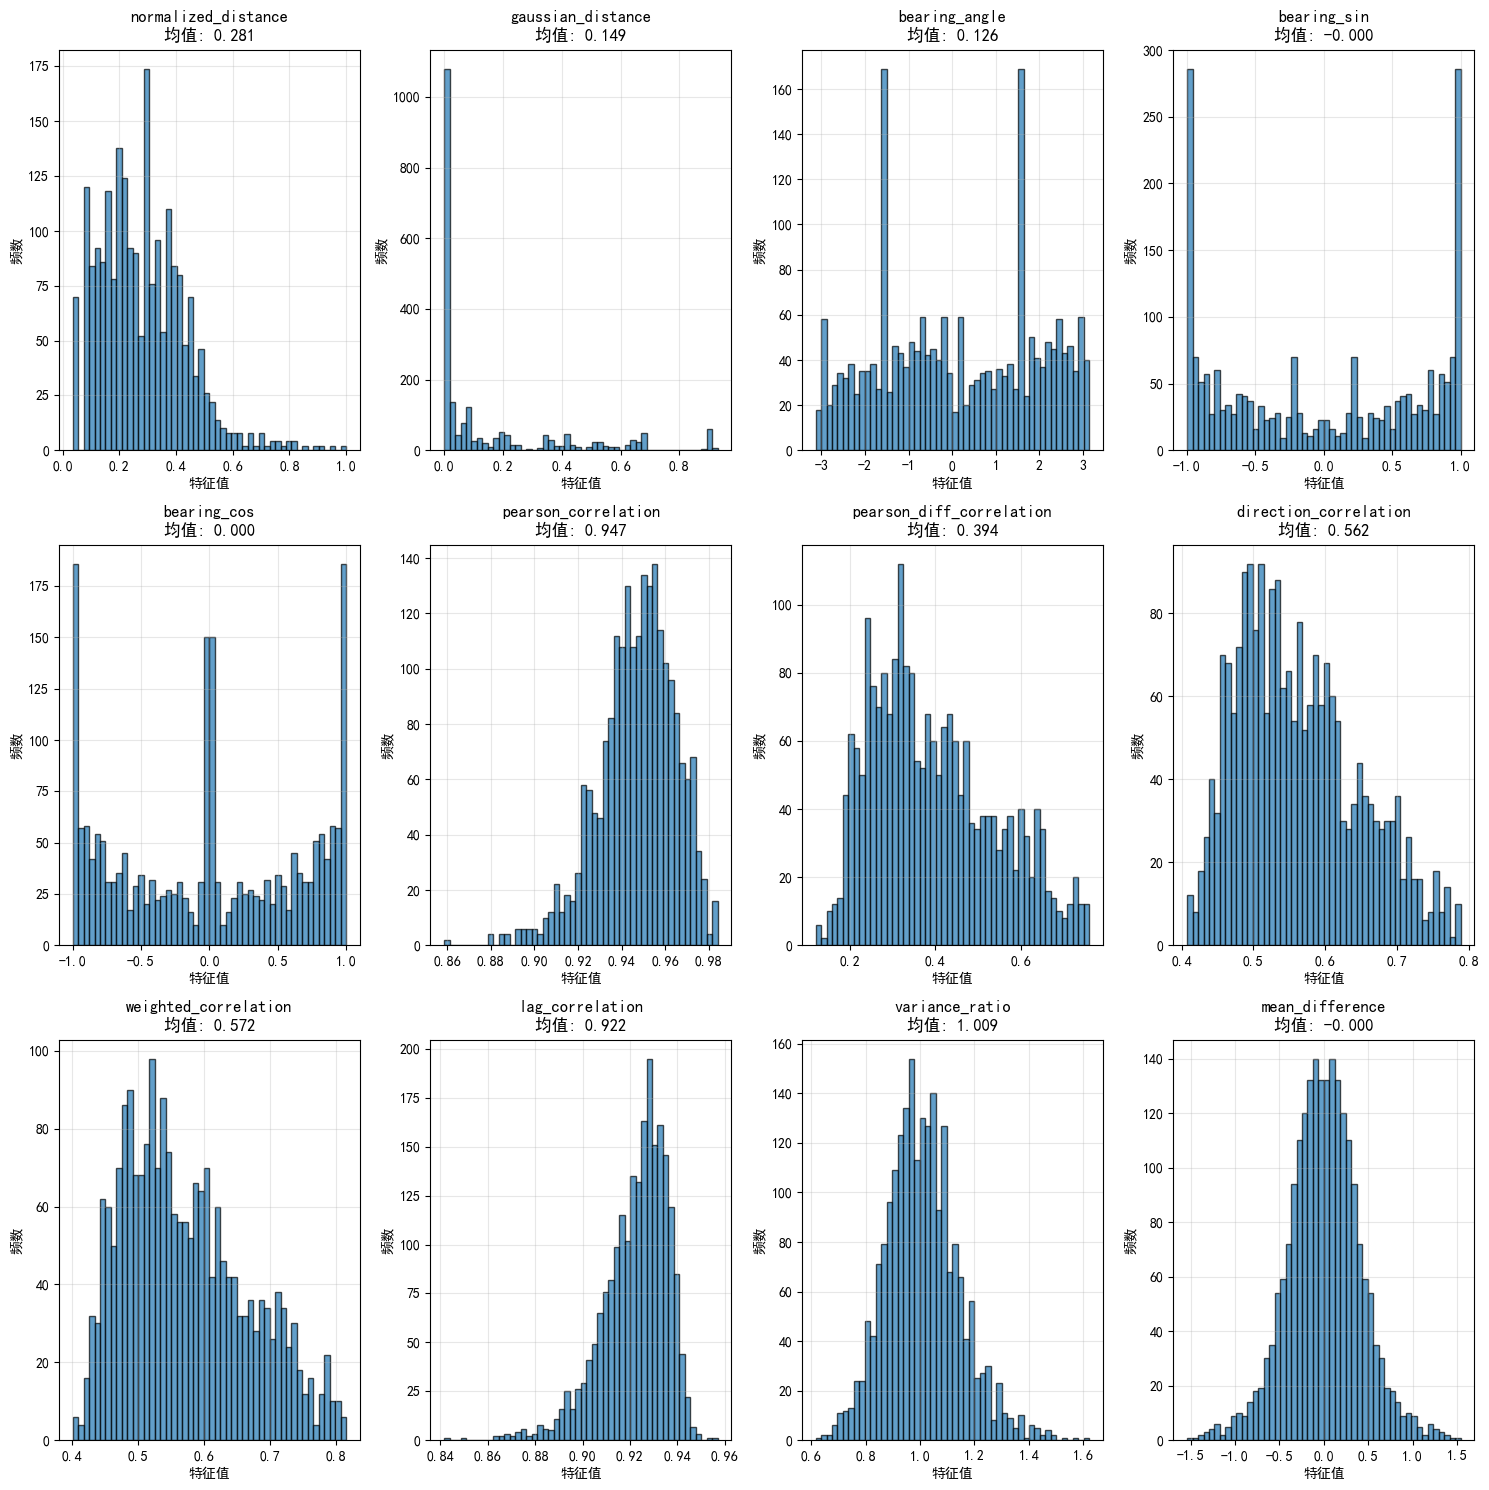

特征分布图已保存为 all_edge_features_distribution_cluster0.png


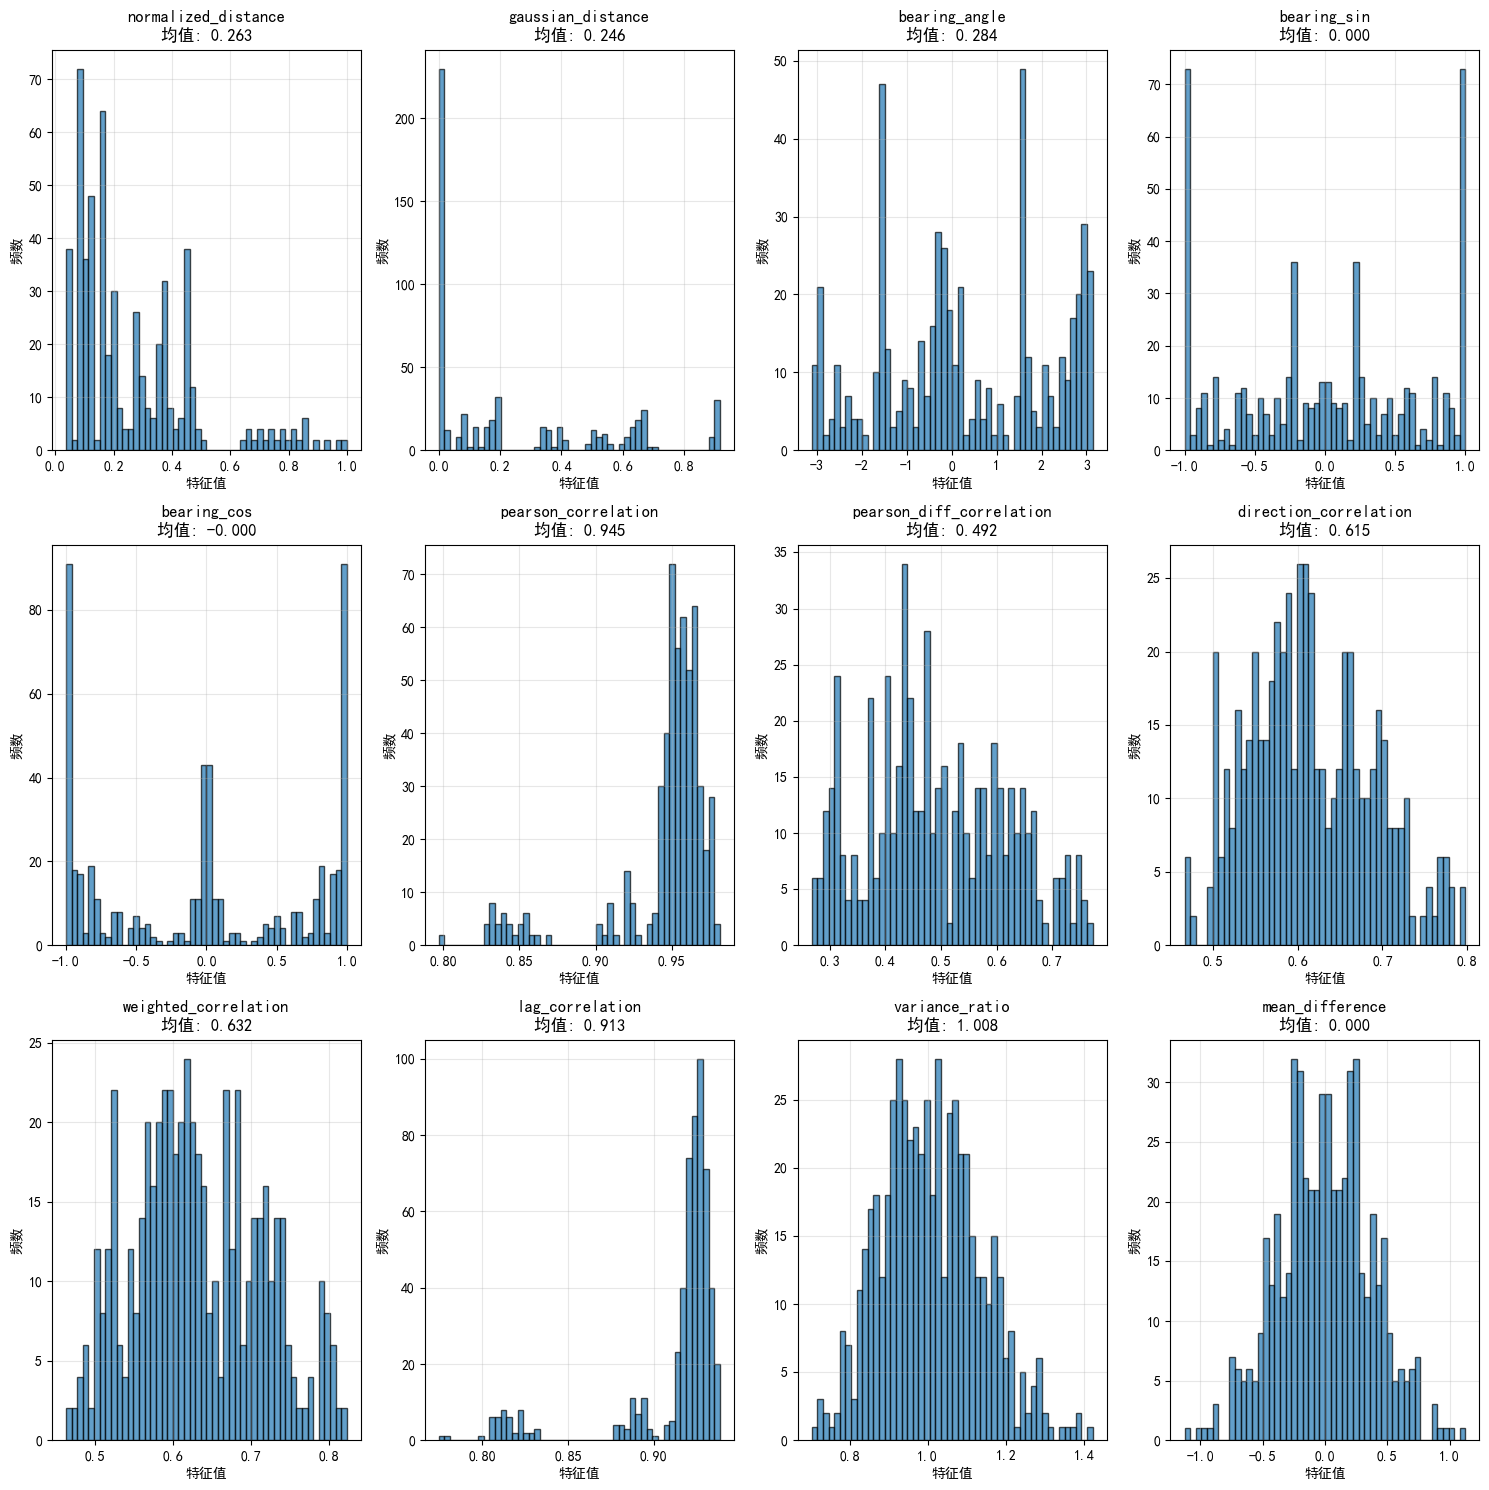

特征分布图已保存为 all_edge_features_distribution_cluster1.png


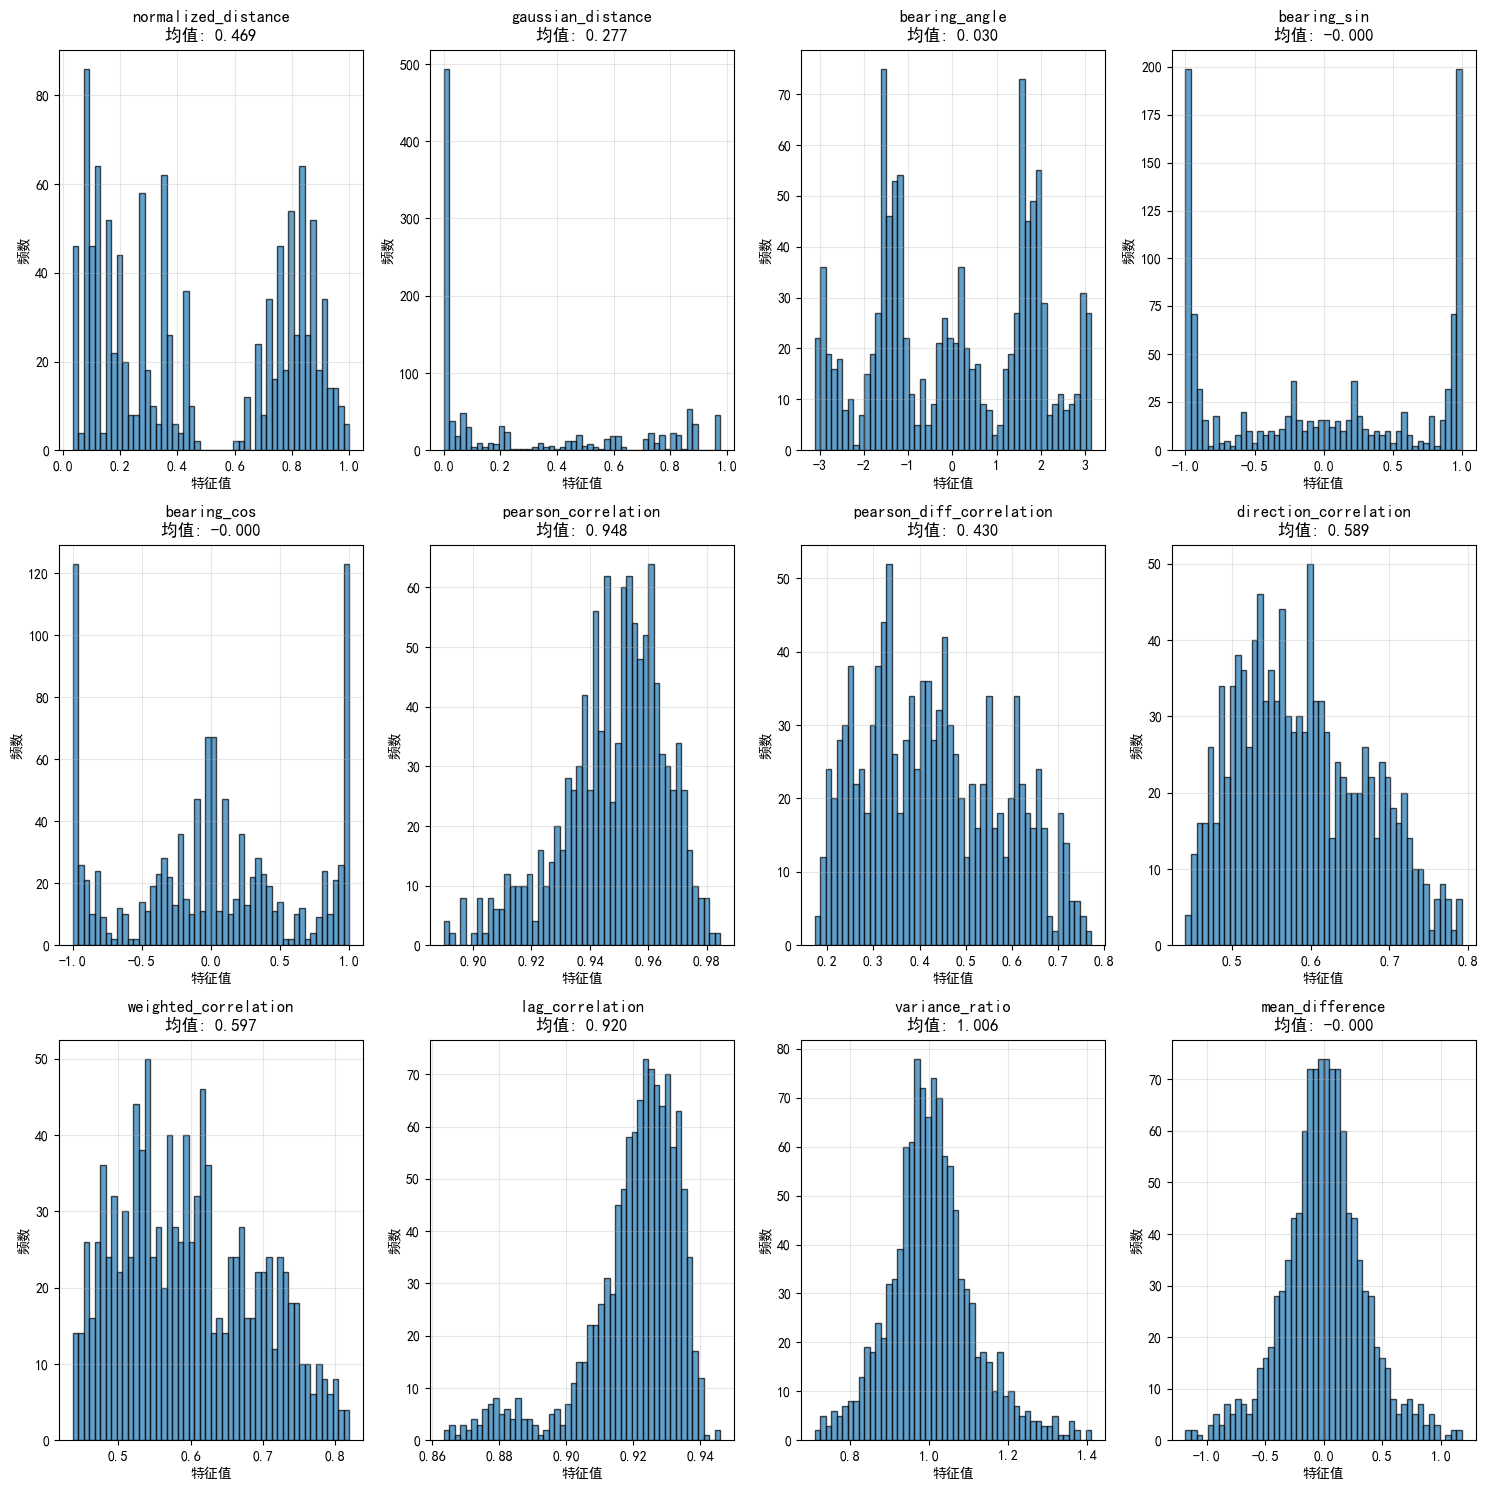

特征分布图已保存为 all_edge_features_distribution_cluster2.png


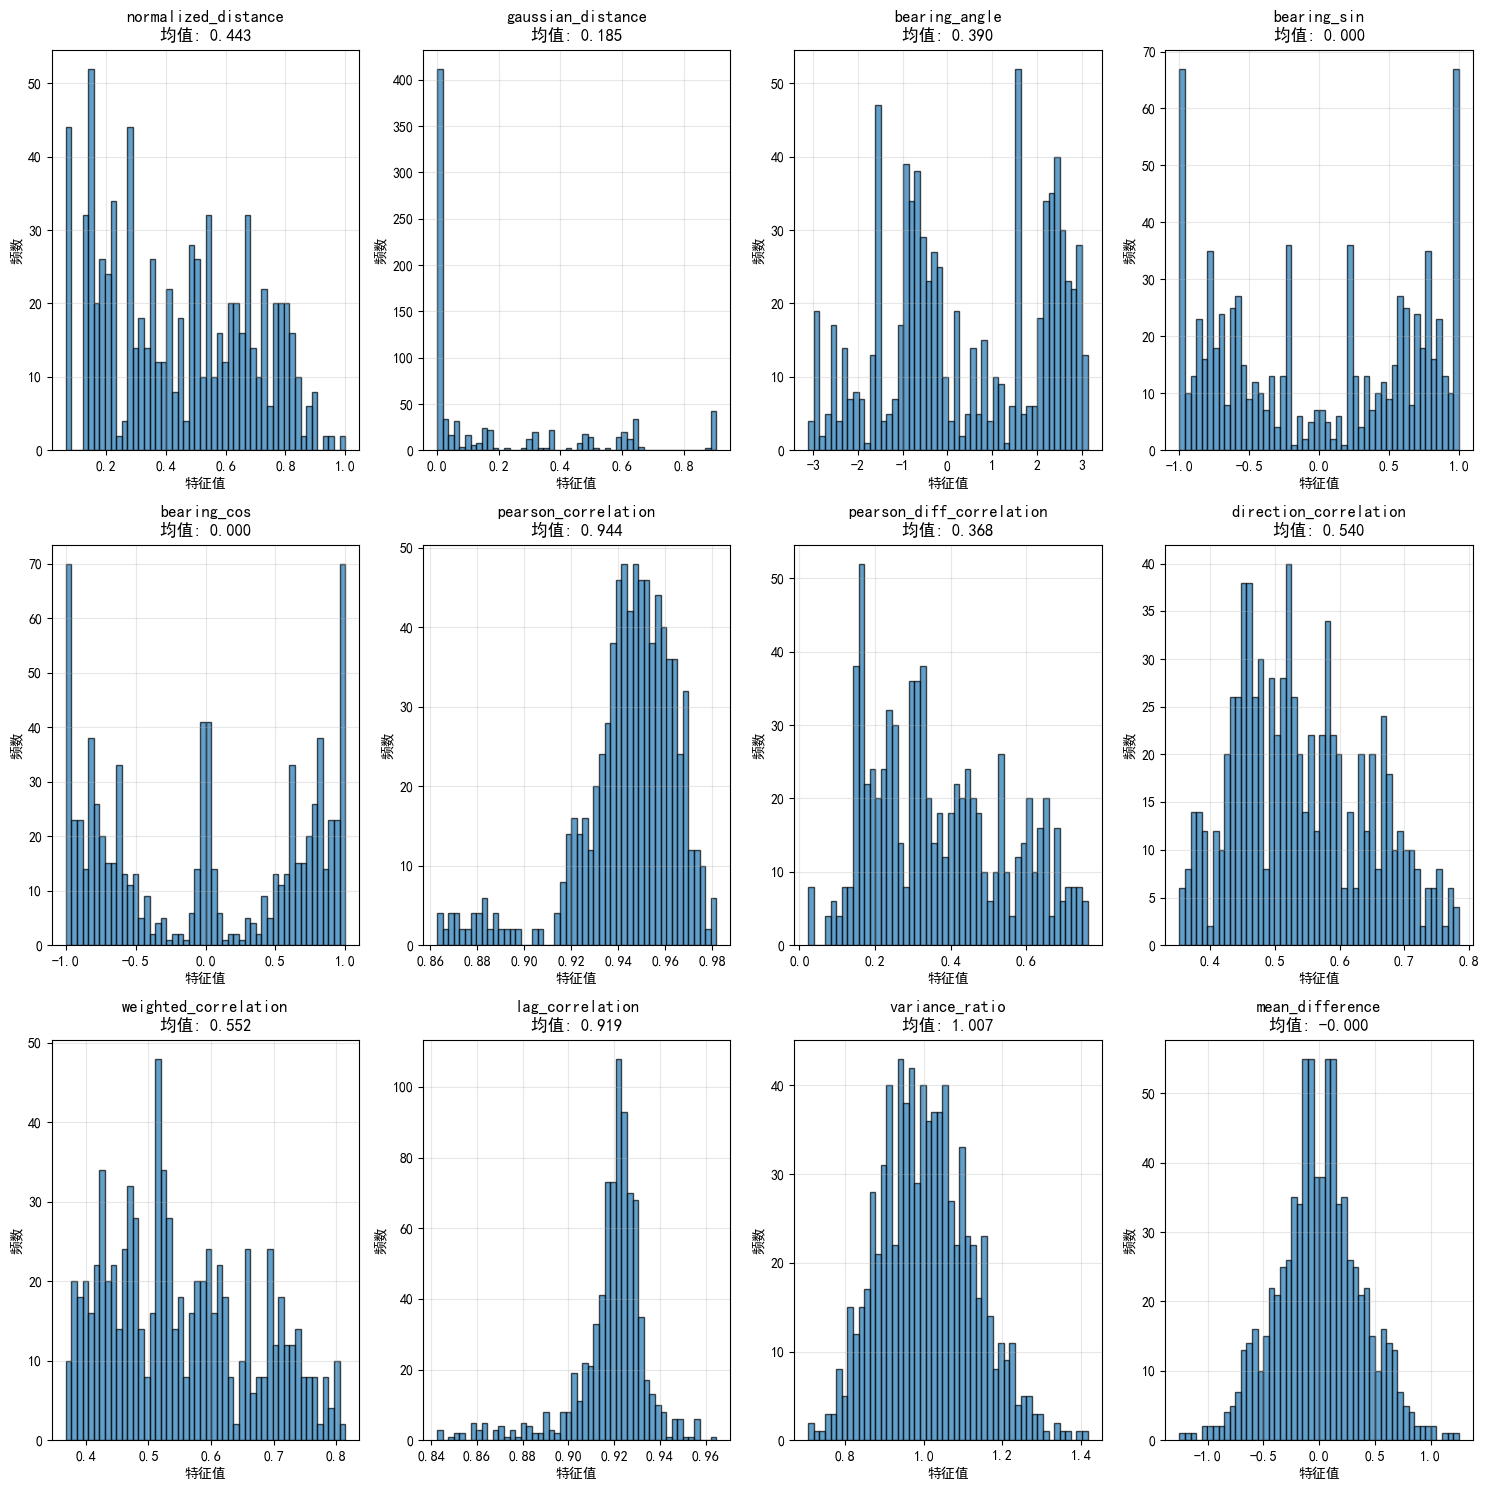

特征分布图已保存为 all_edge_features_distribution_cluster3.png

5. 创建full图...

6. 创建PyTorch Geometric数据...
cluster0边特征张量构建完成:
  边数量: 2162
  特征维度: 12
  特征名称: ['normalized_distance', 'gaussian_distance', 'bearing_angle', 'bearing_sin', 'bearing_cos', 'pearson_correlation', 'pearson_diff_correlation', 'direction_correlation', 'weighted_correlation', 'lag_correlation', 'variance_ratio', 'mean_difference']
cluster1边特征张量构建完成:
  边数量: 552
  特征维度: 12
  特征名称: ['normalized_distance', 'gaussian_distance', 'bearing_angle', 'bearing_sin', 'bearing_cos', 'pearson_correlation', 'pearson_diff_correlation', 'direction_correlation', 'weighted_correlation', 'lag_correlation', 'variance_ratio', 'mean_difference']
cluster2边特征张量构建完成:
  边数量: 1122
  特征维度: 12
  特征名称: ['normalized_distance', 'gaussian_distance', 'bearing_angle', 'bearing_sin', 'bearing_cos', 'pearson_correlation', 'pearson_diff_correlation', 'direction_correlation', 'weighted_correlation', 'lag_correlation', 'variance_ratio', 'mean_difference']
cluster3边

In [78]:
graph_type='full'
k=5

pearson_correlation_matrix_path = "/mnt/EDisk/MyProject/WindSeedForecasting/Time-Series-Library/analysis/graph/2_cluster/wind_speed_correlation_matrices.npz"
pearson_diff_correlation_matrix_path = "/mnt/EDisk/MyProject/WindSeedForecasting/Time-Series-Library/analysis/graph/2_cluster/wind_speed_diff_correlation_matrices.npz"
pearson_direction_correlation_matrix_path = "/mnt/EDisk/MyProject/WindSeedForecasting/Time-Series-Library/analysis/graph/2_cluster/weighted_correlation_matrix.npz"

pearson_correlation_matrix = np.load(pearson_correlation_matrix_path)['original']
pearson_diff_correlation_matrix = np.load(pearson_diff_correlation_matrix_path)['original']
pearson_direction_correlation_matrix = np.load(pearson_direction_correlation_matrix_path)['original']

print("1. 加载相关性矩阵")
print(pearson_correlation_matrix.shape)
print(pearson_diff_correlation_matrix.shape)
print(pearson_direction_correlation_matrix.shape)
print("==============================================================")
# 初始化构建器
builder = EdgeFeatureGraphBuilder(
    base_path = "/mnt/EDisk/MyProject/WindSeedForecasting/Time-Series-Library/dataset/spatial_graph",
    location_file = "sdwpf_baidukddcup2022_turb_location.CSV", 
    correlation_matrices=[
        pearson_correlation_matrix,
        pearson_diff_correlation_matrix,
        pearson_direction_correlation_matrix
    ],
    node_index_file="../2_cluster/node_index.npy",
    files_pattern="dated_Turb*.csv"
)
print("==============================================================")

# 加载风速数据
print("2. 从CSV文件加载风速数据...")
wind_speed_data = builder.load_wind_speed_data()
print("==============================================================")


# 3. 构建边特征
print("3. 构建边特征")
feature_types = ['spatial']  # 空间特征始终包含
feature_types.append('correlation')
feature_types.append('statistical')

edge_features = builder.build_edge_features(feature_types)
print(f"构建{len(edge_features[0])}种边特征")
print("==============================================================")

# 4. 可视化特征分布
print(f"\n4. 可视化特征分布...")
builder.visualize_edge_features(save_path="all_edge_features_distribution_cluster{}.png")
print("==============================================================")

# 5. 创建图
print(f"\n5. 创建{graph_type}图...")
Gs, adj_matrices = builder.create_graph_with_features(graph_type=graph_type, k=k)
print("==============================================================")

# 6. 创建PyTorch Geometric格式数据
print(f"\n6. 创建PyTorch Geometric数据...")
edge_index, edge_attr, feature_names = builder.save_edge_features_for_pytorch_geometric(
    adj_matrices, f"all_edge_feature_{graph_type}"
)
print("==============================================================")

for G in Gs:
    print(f"\n=== 构建完成 ===")
    print(f"图统计:")
    print(f"  节点数: {G.number_of_nodes()}")
    print(f"  边数: {G.number_of_edges()}")
    print(f"  边特征维度: {len(feature_names)}")
    print(f"  特征列表: {feature_names}")

In [81]:
with open("all_edge_feature_full.pkl", 'rb') as f:
    data = pickle.load(f)
print(data.keys())
edge_index = data['edge_index']
print(edge_index)
print(data['node_index'])

dict_keys(['edge_index', 'edge_attr', 'feature_names', 'cluster_coords', 'node_index', 'num_clusters'])
[array([[ 0,  0,  0, ..., 46, 46, 46],
       [ 1,  2,  3, ..., 43, 44, 45]]), array([[ 0,  0,  0, ..., 23, 23, 23],
       [ 1,  2,  3, ..., 20, 21, 22]]), array([[ 0,  0,  0, ..., 33, 33, 33],
       [ 1,  2,  3, ..., 30, 31, 32]]), array([[ 0,  0,  0, ..., 28, 28, 28],
       [ 1,  2,  3, ..., 25, 26, 27]])]
[array([  0,   1,   3,   4,   5,   6,   7,   8,   9,  10,  12,  21,  22,
        23,  24,  25,  26,  27,  28,  29,  30,  31,  44,  45,  46,  47,
        48,  49,  50,  51,  52,  68,  69,  70,  71,  72,  73,  74,  76,
        90,  91,  92,  93, 112, 113, 114, 115]), array([ 59,  60,  61,  62,  63,  82,  83,  84,  85,  86,  87, 101, 102,
       103, 104, 105, 106, 122, 123, 124, 125, 126, 127, 128]), array([ 11,  13,  14,  32,  33,  34,  35,  36,  37,  53,  54,  55,  56,
        57,  58,  75,  77,  78,  79,  80,  81,  94,  95,  96,  97,  98,
        99, 100, 116, 117, 118, 119, 